# FCD Travel Time Analysis (schlanke Version)

- Interaktives Linien-Zeichnen ausschließlich über Schritt "Karte öffnen und GeoJSON exportieren" 
- Danach werden die gezeichneten Linien (GeoJSON) geladen und als `line_a`/`line_b` verwendet
- Parameter zentral, vereinheitlichte Struktur, kleinere Robustheitsverbesserungen


In [26]:
# Imports & Konfiguration
from pathlib import Path
import os
import json
import numpy as np
import pandas as pd
from math import isfinite
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import LineString, shape, mapping
from pyproj import Geod

# Visual defaults
sns.set_theme(style="whitegrid", context="talk")

# Geodätisches Modell
geod = Geod(ellps="WGS84")

# Parameter
CSV_PATH = (Path("..") / ".." / "input" / "FCD" / "Bohlweg 2021" / "FCD_Bohlweg_Su\u0308d_Nord.csv").resolve()
LONG_STOP_THRESHOLD_S = 600  # Entferne Trajektorien mit Halten > 600 s an einem Ort
STOP_SPEED_THRESHOLD_KMH = 0.1
MIN_STOP_POINTS = 2
DISTANCE_CUT_M = 700
START_COORDS = [52.2658, 10.5302]  # Startkarte

# Hilfs-Konstanten
KMH_TO_MPS = 1000.0 / 3600.0
TIME_PERIOD_DEFINITIONS = [
    ("Morning Peak (06\u201309)", 6, 9),
    ("Midday (09\u201315)", 9, 15),
    ("Afternoon Peak (15\u201319)", 15, 19),
    ("Evening (19\u201322)", 19, 22),
    ("Night (22\u201306)", 22, 24),
    ("Night (22\u201306)", 0, 6)
]

COLUMN_RENAMES = {
    "traj_id": "Trajectory ID",
    "Veh_ID": "Trip ID",
    "line_a_time": "Line A Crossing Time",
    "line_b_time": "Line B Crossing Time",
    "segment_weekday": "Segment Weekday (Mon=0)",
    "segment_time_period": "Segment Time of Day",
    "travel_time_seconds": "Segment Travel Time (s)",
    "travel_time": "Segment Travel Time",
    "distance_m_between_lines": "Distance Between Lines (m)",
    "avg_speed_kmh_between_lines": "Average Speed Between Lines (km/h)",
    "segment_max_speed_kmh": "Maximum Speed Between Lines (km/h)",
    "segment_stop_count": "Stops Between Lines (count)",
    "segment_stop_time_seconds": "Total Stop Time Between Lines (s)",
    "segment_stop_avg_seconds": "Average Stop Duration Between Lines (s)",
    "segment_stop_max_seconds": "Longest Stop Between Lines (s)",
    "segment_delay_from_stops_seconds": "Stop Delay Between Lines (s)",
    "segment_min_acc_mps2": "Minimum Acceleration Between Lines (m/s^2)",
    "segment_max_acc_mps2": "Maximum Acceleration Between Lines (m/s^2)",
    "segment_avg_acc_mps2": "Average Acceleration Between Lines (m/s^2)",
    "segment_avg_pos_acc_mps2": "Average Positive Acceleration Between Lines (m/s^2)",
    "segment_avg_neg_acc_mps2": "Average Braking Between Lines (m/s^2)",
    "line_a_lon": "Line A Crossing Longitude",
    "line_a_lat": "Line A Crossing Latitude",
    "line_b_lon": "Line B Crossing Longitude",
    "line_b_lat": "Line B Crossing Latitude",
    "Total_Stop_Time": "Trip Total Stop Time (s)",
    "Avg_Stop_Time": "Trip Average Stop Time (s)",
    "Max_Stop_Time": "Trip Longest Stop (s)",
    "Num_Stops": "Trip Number of Stops",
    "Traveltime": "Trip Travel Time (s)",
    "Departure": "Trip Departure Time",
    "Arrival": "Trip Arrival Time"
}


## 1) Daten einlesen und Grundaggregation (Trips)

In [27]:
if not CSV_PATH.exists():
    raise FileNotFoundError(f"Datei nicht gefunden: {CSV_PATH}")

FCD = pd.read_csv(CSV_PATH, sep=';')

# numerische Zeiten sicherstellen
FCD['t1'] = pd.to_numeric(FCD['t1'], errors='coerce')
FCD['t2'] = pd.to_numeric(FCD['t2'], errors='coerce')

# Trajektorien mit sehr langen Halten entfernen (pro Ort x2)
long_stops = FCD.groupby(['traj_id', 'x2']).apply(lambda x: (x['t2'].max() - x['t1'].min()) > LONG_STOP_THRESHOLD_S)
long_stop_ids = long_stops[long_stops].index.get_level_values(0).unique()
FCD = FCD[~FCD['traj_id'].isin(long_stop_ids)].reset_index(drop=True)

# sortieren für alle nachfolgenden Auswertungen
FCD = FCD.sort_values(by=['traj_id', 'traj_seq']).reset_index(drop=True)

# Trip-Start/Ende und Dauer
FCD_times = (
    FCD.groupby('traj_id')
      .agg(Departure=('t1', 'min'), Arrival=('t2', 'max'))
      .dropna()
      .assign(Traveltime=lambda df: df['Arrival'] - df['Departure'])
      .reset_index()
      .rename(columns={'traj_id': 'Veh_ID'})
)
FCD_times['Departure'] = pd.to_datetime(FCD_times['Departure'], unit='s')
FCD_times['Arrival'] = pd.to_datetime(FCD_times['Arrival'], unit='s')

print("Anzahl Trajektorien (ohne sehr lange Halte):", FCD['traj_id'].nunique())
FCD.head(2)

Anzahl Trajektorien (ohne sehr lange Halte): 4201


/var/folders/0m/qk4p0csd6_34gwkb9phn6gcw0000gn/T/ipykernel_84752/3455322233.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  long_stops = FCD.groupby(['traj_id', 'x2']).apply(lambda x: (x['t2'].max() - x['t1'].min()) > LONG_STOP_THRESHOLD_S)


,traj_id,traj_seq,old_lon,old_lat,new_lon,new_lat,old_point_wkt,new_point_wkt,x1,x2,t1,t2,v1,v2,time_diff
0,-1000068661_1635516934,0,10.522408,52.266698,10.522408,52.266698,POINT(10.5224082878646 52.2666982341701),POINT(10.5224082878646 52.2666982341701),-370.041521,-370.041521,NaN,1635516934,NaN,0.0,NaN
1,-1000068661_1635516934,1,10.522408,52.266698,10.522408,52.266698,POINT(10.5224082878646 52.2666982341701),POINT(10.5224082878646 52.2666982341701),-370.041521,-370.041521,1.635517e+09,1635516949,0.0,2.0,15.0


## 2) Stopperkennung pro Trajektorie (für spätere Segment-Statistiken)

In [28]:
FCD['v2'] = pd.to_numeric(FCD.get('v2'), errors='coerce')
FCD['is_stop'] = FCD['v2'] < STOP_SPEED_THRESHOLD_KMH
FCD['stop_group'] = (FCD['is_stop'] != FCD['is_stop'].shift()).cumsum()
FCD['stop_group_size'] = 0
FCD['is_valid_stop'] = False

stops_only = FCD[FCD['is_stop']].copy()
if not stops_only.empty:
    group_sizes = stops_only.groupby(['traj_id', 'stop_group'])['is_stop'].transform('size')
    valid_mask = group_sizes >= MIN_STOP_POINTS
    FCD.loc[stops_only.index, 'stop_group_size'] = group_sizes
    FCD.loc[stops_only.index, 'is_valid_stop'] = valid_mask.values

# Koordinatenspalten bestimmen
if 'y2' in FCD.columns:
    STOP_X_COL, STOP_Y_COL = 'x2', 'y2'
else:
    coord_cols = [c for c in FCD.columns if c.lower().startswith('x')]
    if len(coord_cols) >= 2:
        STOP_X_COL, STOP_Y_COL = coord_cols[:2]
    elif len(coord_cols) == 1:
        STOP_X_COL = STOP_Y_COL = coord_cols[0]
    else:
        STOP_X_COL, STOP_Y_COL = None, None

FCD[['traj_id','traj_seq','is_stop','is_valid_stop','stop_group']].head()

,traj_id,traj_seq,is_stop,is_valid_stop,stop_group
0,-1000068661_1635516934,0,True,False,1
1,-1000068661_1635516934,1,False,False,2
2,-1000068661_1635516934,2,True,True,3
3,-1000068661_1635516934,3,True,True,3
4,-1000068661_1635516934,4,True,True,3


## 3) WKT-Punkte parsen und Trajektorien-Punkte erzeugen (für Plot/Analyse)

In [29]:
def parse_point_wkt(wkt: str):
    if isinstance(wkt, str):
        wkt = wkt.strip()
        if wkt.upper().startswith('POINT') and '(' in wkt and ')' in wkt:
            try:
                coord_part = wkt[wkt.find('(')+1:wkt.find(')')]
                lon_str, lat_str = coord_part.split()
                return float(lon_str), float(lat_str)
            except ValueError:
                return (np.nan, np.nan)
    return (np.nan, np.nan)

old_wkt_candidates = [c for c in FCD.columns if 'wkt' in c.lower() and any(k in c.lower() for k in ['old','start'])]
new_wkt_candidates = [c for c in FCD.columns if 'wkt' in c.lower() and any(k in c.lower() for k in ['new','end'])]
if not old_wkt_candidates or not new_wkt_candidates:
    raise ValueError('Keine geeigneten WKT-Spalten für Start/Ende gefunden.')

old_wkt_col, new_wkt_col = old_wkt_candidates[0], new_wkt_candidates[0]

FCD[['old_lon','old_lat']] = pd.DataFrame(FCD[old_wkt_col].apply(parse_point_wkt).tolist(), index=FCD.index)
FCD[['new_lon','new_lat']] = pd.DataFrame(FCD[new_wkt_col].apply(parse_point_wkt).tolist(), index=FCD.index)

traj_points_list = []
for traj_id, group in FCD.groupby('traj_id', sort=False):
    group = group.sort_values('traj_seq')
    # erster gültiger old
    first_valid_old = None
    for lon, lat in group[['old_lon','old_lat']].to_numpy(dtype=float):
        if np.isfinite(lon) and np.isfinite(lat):
            first_valid_old = (lon, lat)
            break
    coords = []
    if first_valid_old is not None:
        coords.append(first_valid_old)
    for lon, lat in group[['new_lon','new_lat']].to_numpy(dtype=float):
        if np.isfinite(lon) and np.isfinite(lat):
            coords.append((lon, lat))
    if len(coords) < 2:
        continue
    traj_df = pd.DataFrame(coords, columns=['lon','lat'])
    traj_df['traj_id'] = traj_id
    traj_df['point_order'] = range(len(traj_df))
    traj_points_list.append(traj_df)

traj_points = pd.concat(traj_points_list, ignore_index=True) if traj_points_list else pd.DataFrame(columns=['traj_id','point_order','lon','lat'])
traj_points.head()

,lon,lat,traj_id,point_order
0,10.522408,52.266698,-1000068661_1635516934,0
1,10.522408,52.266698,-1000068661_1635516934,1
2,10.522408,52.266698,-1000068661_1635516934,2
3,10.522408,52.266698,-1000068661_1635516934,3
4,10.522408,52.266698,-1000068661_1635516934,4


## 4) Karte öffnen, Linien zeichnen und als GeoJSON exportieren (einziger Interaktiv-Schritt)
- Im Browser Linien zeichnen und oben rechts per Export-Button als GeoJSON speichern
- Danach Pfad zur exportierten GeoJSON-Datei eingeben
- Die ersten zwei LineStrings werden als `line_a` und `line_b` verwendet (Reihenfolge = Export-Reihenfolge)

In [30]:
import folium
from folium import plugins
import webbrowser

# Karte erzeugen und im Browser öffnen
m = folium.Map(location=START_COORDS, zoom_start=16, tiles='OpenStreetMap')
draw = plugins.Draw(
    export=True,
    filename='lines.geojson',
    position='topright',
    draw_options={
        'polyline': True,
        'polygon': False,
        'circle': False,
        'rectangle': False,
        'marker': False
    },
    edit_options={'edit': True}
)
draw.add_to(m)
map_filename = 'meine_karte.html'
m.save(map_filename)
try:
    webbrowser.open('file://' + os.path.realpath(map_filename))
except Exception as e:
    print('Hinweis: Karte konnte nicht automatisch geöffnet werden:', e)
print('Karte geöffnet. Zeichne Linien und exportiere als GeoJSON (Button oben rechts).')



Karte geöffnet. Zeichne Linien und exportiere als GeoJSON (Button oben rechts).


In [31]:
# GeoJSON laden
#geojson_file = input("\nPfad zur exportierten GeoJSON-Datei (z. B. lines.geojson): ").strip()
geojson_file = Path.home() / "Downloads" / "lines.geojson"
if not geojson_file:
    geojson_file = 'lines.geojson'
if not os.path.exists(geojson_file):
    raise FileNotFoundError(f"GeoJSON-Datei nicht gefunden: {geojson_file}")

with open(geojson_file, 'r') as f:
    lines_data = json.load(f)
if 'features' not in lines_data or len(lines_data['features']) < 2:
    raise ValueError('Es werden mindestens zwei Linien (LineString) im GeoJSON benötigt.')

# Shapely-Geometrien extrahieren
line_geoms = []
for feat in lines_data['features']:
    geom = shape(feat['geometry'])
    if geom.geom_type == 'LineString':
        line_geoms.append(geom)
if len(line_geoms) < 2:
    raise ValueError('GeoJSON enthält weniger als zwei LineStrings.')

line_a, line_b = line_geoms[0], line_geoms[1]

# Längen ausgeben
len_a = geod.geometry_length(line_a)
len_b = geod.geometry_length(line_b)
print(f"\nLinie A Länge: {len_a:.2f} m, Linie B Länge: {len_b:.2f} m")

# Ergebnis-Karte rendern
result_map = folium.Map(location=START_COORDS, zoom_start=16, tiles='CartoDB Positron')
for geom in line_geoms:
    coords = list(geom.coords)
    folium.PolyLine([(lat, lon) for lon, lat in coords], color='orange', weight=5, opacity=0.8).add_to(result_map)
result_filename = 'linien_ergebnis.html'
result_map.save(result_filename)
try:
    webbrowser.open('file://' + os.path.realpath(result_filename))
except Exception:
    pass
print(f"Ergebnis-Karte gespeichert in '{result_filename}'.")


Linie A Länge: 146.52 m, Linie B Länge: 165.35 m
Ergebnis-Karte gespeichert in 'linien_ergebnis.html'.


In [39]:
# Nach Schritt 4b ausführen
from shapely.geometry import LineString

def sanity_check_and_fix_lines(FCD, line_a, line_b, max_traj=100):
    import numpy as np
    stats = {'A':0,'B':0,'both':0,'B_before_A':0,'checked':0}
    samples = []

    def _first_cross_order(g):
        first = None; seenA = seenB = False
        g = g.sort_values('traj_seq')
        for _, r in g.iterrows():
            if not (np.isfinite([r.old_lon, r.old_lat, r.new_lon, r.new_lat]).all()):
                continue
            seg = LineString([(r.old_lon, r.old_lat), (r.new_lon, r.new_lat)])
            if seg.is_empty or not seg.is_valid:
                continue
            if seg.intersects(line_a) and not seenA:
                seenA = True
                if first is None: first = 'A'
            if seg.intersects(line_b) and not seenB:
                seenB = True
                if first is None: first = 'B'
            if seenA and seenB:
                break
        return first, seenA, seenB

    for tid, g in list(FCD.groupby('traj_id', sort=False))[:max_traj]:
        first, sa, sb = _first_cross_order(g)
        stats['A'] += int(sa); stats['B'] += int(sb); stats['both'] += int(sa and sb); stats['checked'] += 1
        if sa and sb and first == 'B':
            stats['B_before_A'] += 1
            if len(samples) < 2:
                samples.append(tid)

    print(f"Sanity: checked={stats['checked']} hitA={stats['A']} hitB={stats['B']} both={stats['both']} "
          f"B_before_A={stats['B_before_A']} samples={samples}")

    # Wenn die Mehrheit der 'both'-Fälle mit B vor A ist, Linien tauschen
    if stats['both'] > 0 and stats['B_before_A'] / stats['both'] > 0.7:
        print("Hinweis: Viele 'B vor A' → Linien werden getauscht (A<->B).")
        return line_b, line_a
    return line_a, line_b

# Anwenden:
line_a, line_b = sanity_check_and_fix_lines(FCD, line_a, line_b)

Sanity: checked=100 hitA=100 hitB=98 both=98 B_before_A=2 samples=['-1035415316_1635624907', '-1082492159_1633185539']


## 5) Segmentermittlung: Querung zwischen `line_a` und `line_b` je Trajektorie

In [32]:
def geodesic_distance_m(lon1, lat1, lon2, lat2):
    vals = (lon1, lat1, lon2, lat2)
    if any(v is None or not isfinite(v) for v in vals):
        return np.nan
    _, _, dist = geod.inv(lon1, lat1, lon2, lat2)
    return float(abs(dist))

def intersection_details(old_lon, old_lat, new_lon, new_lat, query_line):
    vals = (old_lon, old_lat, new_lon, new_lat)
    if any(v is None or not isfinite(v) for v in vals):
        return None
    segment = LineString([(old_lon, old_lat), (new_lon, new_lat)])
    if segment.is_empty or segment.length == 0:
        return None
    inter = segment.intersection(query_line)
    if inter.is_empty:
        return None
    if inter.geom_type == 'Point':
        points = [inter]
    elif inter.geom_type == 'MultiPoint':
        points = list(inter.geoms)
    elif inter.geom_type in {'LineString', 'LinearRing'}:
        boundary = inter.boundary
        points = list(boundary.geoms) if hasattr(boundary, 'geoms') else [boundary]
    elif inter.geom_type == 'GeometryCollection':
        points = [g for g in inter.geoms if g.geom_type == 'Point']
        if not points:
            return None
    else:
        return None
    distances = [segment.project(pt) for pt in points]
    if not distances:
        return None
    distance_along = min(distances)
    fraction = distance_along / segment.length if segment.length != 0 else 0.0
    point = segment.interpolate(distance_along)
    lon_i, lat_i = point.x, point.y
    distance_from_start = geodesic_distance_m(old_lon, old_lat, lon_i, lat_i)
    return { 'fraction': fraction, 'point': (lon_i, lat_i), 'distance_from_start_m': distance_from_start }

def weighted_average(values, weights):
    mask = (~np.isnan(values)) & (~np.isnan(weights)) & (weights > 0)
    return float(np.average(values[mask], weights=weights[mask])) if mask.any() else np.nan

def determine_time_period(ts):
    if pd.isna(ts):
        return np.nan
    hour = ts.hour + ts.minute / 60
    for label, start_hour, end_hour in TIME_PERIOD_DEFINITIONS:
        if start_hour <= end_hour:
            if start_hour <= hour < end_hour:
                return label
        else:
            if hour >= start_hour or hour < end_hour:
                return label
    return 'Night (22\u201306)'

crossings = []
segment_stop_details_records = []

for traj_id, group in FCD.groupby('traj_id', sort=False):
    group_sorted = group.sort_values('traj_seq').reset_index(drop=True)
    line_a_info, line_b_info = None, None
    distance_accum = 0.0
    prev_point = None
    crossed_b_before_a = False

    for _, row in group_sorted.iterrows():
        old_lon, old_lat = row.old_lon, row.old_lat
        new_lon, new_lat = row.new_lon, row.new_lat
        t_start, t_end = row.t1, row.t2
        if any(v is None or not isfinite(v) for v in [old_lon, old_lat, new_lon, new_lat, t_start, t_end]):
            if line_a_info is not None:
                prev_point = None
            continue

        detail_a = None
        if line_a_info is None:
            detail_a = intersection_details(old_lon, old_lat, new_lon, new_lat, line_a)
            if detail_a is not None:
                fa = detail_a['fraction']
                line_a_time = float(t_start + fa * (t_end - t_start))
                line_a_info = { 'time': line_a_time, 'point': detail_a['point'], 'fraction': fa }
                prev_point = detail_a['point']
                distance_accum = 0.0

        detail_b = intersection_details(old_lon, old_lat, new_lon, new_lat, line_b)
        if line_a_info is None and detail_b is not None:
            crossed_b_before_a = True
            break
        if line_a_info is None:
            continue

        same_segment_as_a = detail_a is not None
        if line_b_info is None and detail_b is not None:
            fb = detail_b['fraction']
            if (not same_segment_as_a) or (fb >= line_a_info['fraction']):
                if prev_point is None:
                    prev_point = (old_lon, old_lat)
                b_point = detail_b['point']
                dist_inc = geodesic_distance_m(prev_point[0], prev_point[1], b_point[0], b_point[1])
                if np.isfinite(dist_inc):
                    distance_accum += dist_inc
                line_b_time = float(t_start + fb * (t_end - t_start))
                line_b_info = { 'time': line_b_time, 'point': b_point }
                prev_point = b_point
                break

        if line_b_info is None:
            if prev_point is None:
                prev_point = (old_lon, old_lat)
            dist_inc = geodesic_distance_m(prev_point[0], prev_point[1], new_lon, new_lat)
            if np.isfinite(dist_inc):
                distance_accum += dist_inc
            prev_point = (new_lon, new_lat)

    if crossed_b_before_a or line_a_info is None or line_b_info is None:
        continue

    travel_time_seconds = line_b_info['time'] - line_a_info['time']
    if travel_time_seconds <= 0:
        continue

    line_a_time = line_a_info['time']
    line_b_time = line_b_info['time']
    segment_mask = (group_sorted['t2'] > line_a_time) & (group_sorted['t1'] < line_b_time)
    segment_df = group_sorted.loc[segment_mask].copy()
    if not segment_df.empty:
        segment_df['segment_overlap_start'] = np.maximum(segment_df['t1'], line_a_time)
        segment_df['segment_overlap_end'] = np.minimum(segment_df['t2'], line_b_time)
        segment_df['segment_overlap_duration'] = np.maximum(0.0, segment_df['segment_overlap_end'] - segment_df['segment_overlap_start'])
    else:
        segment_df = group_sorted.iloc[0:0].copy()

    # Stopps im Zeitfenster
    segment_stop_count = 0
    segment_stop_time = 0.0
    segment_stop_max = 0.0
    segment_stop_avg = 0.0

    if {'is_valid_stop','stop_group'}.issubset(segment_df.columns):
        stop_df = segment_df[(segment_df['is_valid_stop']) & (segment_df['segment_overlap_duration'] > 0)]
        if not stop_df.empty:
            grouped_stops = stop_df.groupby('stop_group')
            stop_summary = grouped_stops.agg(overlap_start=('segment_overlap_start','min'), overlap_end=('segment_overlap_end','max'))
            stop_summary['stop_time'] = np.maximum(0.0, stop_summary['overlap_end'] - stop_summary['overlap_start'])
            stop_summary = stop_summary[stop_summary['stop_time'] > 0]
            if not stop_summary.empty:
                segment_stop_count = int(stop_summary.shape[0])
                segment_stop_time = float(stop_summary['stop_time'].sum())
                segment_stop_max = float(stop_summary['stop_time'].max())
                segment_stop_avg = float(segment_stop_time / segment_stop_count) if segment_stop_count else 0.0
                detailed = stop_summary.copy()
                if 'v2' in stop_df.columns:
                    detailed['mean_speed'] = grouped_stops['v2'].mean().astype(float)
                if STOP_X_COL and STOP_X_COL in stop_df.columns:
                    detailed['mean_x'] = grouped_stops[STOP_X_COL].mean().astype(float)
                if STOP_Y_COL and STOP_Y_COL in stop_df.columns:
                    detailed['mean_y'] = grouped_stops[STOP_Y_COL].mean().astype(float)
                detailed['point_count'] = grouped_stops['segment_overlap_duration'].apply(lambda v: int((v > 0).sum())).astype(int)
                detailed['traj_id'] = traj_id
                detailed['segment_departure_time'] = line_a_time
                detailed['segment_arrival_time'] = line_b_time
                segment_stop_details_records.append(detailed.reset_index())

    # Beschleunigung
    acc_df = segment_df[segment_df['segment_overlap_duration'] > 0].copy()
    if not acc_df.empty:
        acc_df['v1_mps'] = pd.to_numeric(acc_df.get('v1'), errors='coerce') * KMH_TO_MPS
        acc_df['v2_mps'] = pd.to_numeric(acc_df.get('v2'), errors='coerce') * KMH_TO_MPS
        if 'time_diff' in acc_df.columns:
            acc_df['time_diff_s'] = pd.to_numeric(acc_df['time_diff'], errors='coerce')
        else:
            # Fallback: aus t1/t2 berechnen
            acc_df['time_diff_s'] = pd.to_numeric(acc_df['t2'], errors='coerce') - pd.to_numeric(acc_df['t1'], errors='coerce')
        acc_df['acc_mps2'] = np.where(acc_df['time_diff_s'] > 0, (acc_df['v2_mps'] - acc_df['v1_mps']) / acc_df['time_diff_s'], np.nan)
        valid_acc = acc_df[~acc_df['acc_mps2'].isna()]
        if not valid_acc.empty:
            weights = valid_acc['segment_overlap_duration'].to_numpy(dtype=float)
            acc_values = valid_acc['acc_mps2'].to_numpy(dtype=float)
            segment_avg_acc = weighted_average(acc_values, weights)
            segment_min_acc = float(acc_values.min())
            segment_max_acc = float(acc_values.max())
            pos_mask = acc_values > 0
            neg_mask = acc_values < 0
            segment_avg_pos_acc = weighted_average(acc_values[pos_mask], weights[pos_mask]) if pos_mask.any() else np.nan
            segment_avg_neg_acc = weighted_average(acc_values[neg_mask], weights[neg_mask]) if neg_mask.any() else np.nan
        else:
            segment_avg_acc = segment_min_acc = segment_max_acc = segment_avg_pos_acc = segment_avg_neg_acc = np.nan
    else:
        segment_avg_acc = segment_min_acc = segment_max_acc = segment_avg_pos_acc = segment_avg_neg_acc = np.nan

    # Maximalgeschwindigkeit im Segmentfenster
    speed_df = segment_df[segment_df['segment_overlap_duration'] > 0].copy()
    if not speed_df.empty:
        speed_series = []
        for speed_col in ['v1','v2','speed','Velocity','vel','spd']:
            if speed_col in speed_df.columns:
                speed_series.append(pd.to_numeric(speed_df[speed_col], errors='coerce'))
        if speed_series:
            combined_speed = pd.concat(speed_series, axis=1)
            segment_max_speed_kmh = float(np.nanmax(combined_speed.to_numpy()))
        else:
            segment_max_speed_kmh = np.nan
    else:
        segment_max_speed_kmh = np.nan

    crossings.append({
        'traj_id': traj_id,
        'line_a_time': line_a_time,
        'line_b_time': line_b_time,
        'travel_time_seconds': travel_time_seconds,
        'distance_m_between_lines': distance_accum,
        'line_a_lon': line_a_info['point'][0],
        'line_a_lat': line_a_info['point'][1],
        'line_b_lon': line_b_info['point'][0],
        'line_b_lat': line_b_info['point'][1],
        'segment_stop_count': segment_stop_count,
        'segment_stop_time_seconds': segment_stop_time,
        'segment_stop_max_seconds': segment_stop_max,
        'segment_stop_avg_seconds': segment_stop_avg,
        'segment_delay_from_stops_seconds': segment_stop_time,
        'segment_min_acc_mps2': segment_min_acc,
        'segment_max_acc_mps2': segment_max_acc,
        'segment_avg_acc_mps2': segment_avg_acc,
        'segment_avg_pos_acc_mps2': segment_avg_pos_acc,
        'segment_avg_neg_acc_mps2': segment_avg_neg_acc,
        'segment_max_speed_kmh': segment_max_speed_kmh
    })

crossings_df = pd.DataFrame(crossings)

if segment_stop_details_records:
    segment_stop_durations = pd.concat(segment_stop_details_records, ignore_index=True)
    for col in ['segment_departure_time','segment_arrival_time','overlap_start','overlap_end']:
        segment_stop_durations[col] = pd.to_datetime(segment_stop_durations[col], unit='s', utc=True).dt.tz_convert(None)
    segment_stop_durations = segment_stop_durations.rename(columns={
        'traj_id': 'Trajectory ID',
        'stop_group': 'Stop Group',
        'segment_departure_time': 'Segment Departure Time',
        'segment_arrival_time': 'Segment Arrival Time',
        'overlap_start': 'Stop Start Time',
        'overlap_end': 'Stop End Time',
        'stop_time': 'Stop Duration (s)',
        'mean_speed': 'Stop Mean Speed (km/h)',
        'mean_x': 'Stop Mean X',
        'mean_y': 'Stop Mean Y',
        'point_count': 'Stop Point Count'
    })
    if 'Stop Duration (s)' in segment_stop_durations.columns:
        segment_stop_durations['Stop Duration (s)'] = segment_stop_durations['Stop Duration (s)'].astype(float)
    if 'Stop Mean Speed (km/h)' in segment_stop_durations.columns:
        segment_stop_durations['Stop Mean Speed (km/h)'] = segment_stop_durations['Stop Mean Speed (km/h)'].astype(float)
    if 'Stop Point Count' in segment_stop_durations.columns:
        segment_stop_durations['Stop Point Count'] = segment_stop_durations['Stop Point Count'].astype('Int64')
else:
    segment_stop_durations = pd.DataFrame()

if not crossings_df.empty:
    for col in ['line_a_time','line_b_time']:
        crossings_df[col] = pd.to_datetime(crossings_df[col], unit='s', utc=True).dt.tz_convert(None)
    crossings_df['travel_time_seconds'] = crossings_df['travel_time_seconds'].astype(float)
    crossings_df['travel_time'] = pd.to_timedelta(crossings_df['travel_time_seconds'], unit='s')
    crossings_df['distance_m_between_lines'] = crossings_df['distance_m_between_lines'].astype(float)
    crossings_df['segment_stop_time_seconds'] = crossings_df['segment_stop_time_seconds'].astype(float)
    crossings_df['segment_stop_max_seconds'] = crossings_df['segment_stop_max_seconds'].astype(float)
    crossings_df['segment_stop_avg_seconds'] = crossings_df['segment_stop_avg_seconds'].astype(float)
    crossings_df['segment_delay_from_stops_seconds'] = crossings_df['segment_delay_from_stops_seconds'].astype(float)
    crossings_df['segment_max_speed_kmh'] = crossings_df['segment_max_speed_kmh'].astype(float)

    crossings_df = crossings_df.merge(
        FCD_times, how='left', left_on='traj_id', right_on='Veh_ID', suffixes=('', '_full_trip')
    )
    crossings_df['avg_speed_kmh_between_lines'] = np.where(
        crossings_df['travel_time_seconds'] > 0,
        (crossings_df['distance_m_between_lines'] / crossings_df['travel_time_seconds']) * 3.6,
        np.nan
    )
    crossings_df['segment_weekday'] = crossings_df['line_a_time'].dt.weekday
    crossings_df['segment_time_period'] = crossings_df['line_a_time'].apply(determine_time_period)

    preferred_order = [
        'traj_id','Veh_ID','line_a_time','line_b_time','segment_weekday','segment_time_period',
        'travel_time_seconds','travel_time','distance_m_between_lines','avg_speed_kmh_between_lines',
        'segment_max_speed_kmh','segment_stop_count','segment_stop_time_seconds','segment_stop_avg_seconds',
        'segment_stop_max_seconds','segment_delay_from_stops_seconds','segment_min_acc_mps2','segment_max_acc_mps2',
        'segment_avg_acc_mps2','segment_avg_pos_acc_mps2','segment_avg_neg_acc_mps2','line_a_lon','line_a_lat','line_b_lon','line_b_lat',
        'Total_Stop_Time','Avg_Stop_Time','Max_Stop_Time','Num_Stops','Traveltime','Departure','Arrival'
    ]
    existing_preferred = [c for c in preferred_order if c in crossings_df.columns]
    remaining_cols = [c for c in crossings_df.columns if c not in existing_preferred]
    crossings_df = crossings_df[existing_preferred + sorted(remaining_cols)]
    crossings_df = crossings_df.rename(columns=COLUMN_RENAMES)
    crossings_df = crossings_df.sort_values(COLUMN_RENAMES['line_a_time']).reset_index(drop=True)

crossings_df.head()

,Trajectory ID,Trip ID,Line A Crossing Time,Line B Crossing Time,Segment Weekday (Mon=0),Segment Time of Day,Segment Travel Time (s),Segment Travel Time,Distance Between Lines (m),Average Speed Between Lines (km/h),...,Average Acceleration Between Lines (m/s^2),Average Positive Acceleration Between Lines (m/s^2),Average Braking Between Lines (m/s^2),Line A Crossing Longitude,Line A Crossing Latitude,Line B Crossing Longitude,Line B Crossing Latitude,Trip Travel Time (s),Trip Departure Time,Trip Arrival Time
0,509617015_1630448279,509617015_1630448279,2021-08-31 22:19:22.196465969,2021-08-31 22:20:19.430941582,1,Night (22–06),57.234476,0 days 00:00:57.234475613,533.276882,33.542664,...,0.105985,0.342470,-0.503472,10.526304,52.263798,10.526725,52.259205,151.0,2021-08-31 22:17:59,2021-08-31 22:20:30
1,578751466_1630449485,578751466_1630449485,2021-08-31 22:39:10.770705462,2021-08-31 22:40:09.080800772,1,Night (22–06),58.310095,0 days 00:00:58.310095310,538.312340,33.234801,...,0.084369,0.227661,-0.210233,10.526323,52.263798,10.526798,52.259211,165.0,2021-08-31 22:38:05,2021-08-31 22:40:50
2,509617015_1630453834,509617015_1630453834,2021-08-31 23:51:37.147122622,2021-08-31 23:52:25.013794899,1,Night (22–06),47.866672,0 days 00:00:47.866672277,531.464331,39.970850,...,0.134879,0.197555,-0.055556,10.526333,52.263798,10.526668,52.259201,120.0,2021-08-31 23:50:34,2021-08-31 23:52:34
3,-718448254_1630471164,-718448254_1630471164,2021-09-01 04:40:33.524446726,2021-09-01 04:41:46.296012402,2,Night (22–06),72.771566,0 days 00:01:12.771565676,532.389442,26.337237,...,-0.023928,0.574713,-0.420545,10.526242,52.263798,10.526786,52.259210,150.0,2021-09-01 04:39:24,2021-09-01 04:41:54
4,-1217286021_1630480648,-1217286021_1630480648,2021-09-01 07:19:13.407226562,2021-09-01 07:19:57.363281727,2,Morning Peak (06–09),43.956055,0 days 00:00:43.956055164,549.269978,44.985200,...,-0.033260,0.208333,-0.234957,10.526432,52.263798,10.526924,52.259221,295.0,2021-09-01 07:17:28,2021-09-01 07:22:23


In [33]:
# Am Ende von Schritt 5 einfügen
if crossings_df.empty:
    print("Warnung: Keine Querungen gefunden. Prüfe Linien (line_a/line_b) und Daten (WKT, t1/t2).")
else:
    print(f"OK: {len(crossings_df)} Segmente gefunden.")
    display(crossings_df.head(3))

OK: 4009 Segmente gefunden.


,Trajectory ID,Trip ID,Line A Crossing Time,Line B Crossing Time,Segment Weekday (Mon=0),Segment Time of Day,Segment Travel Time (s),Segment Travel Time,Distance Between Lines (m),Average Speed Between Lines (km/h),...,Average Acceleration Between Lines (m/s^2),Average Positive Acceleration Between Lines (m/s^2),Average Braking Between Lines (m/s^2),Line A Crossing Longitude,Line A Crossing Latitude,Line B Crossing Longitude,Line B Crossing Latitude,Trip Travel Time (s),Trip Departure Time,Trip Arrival Time
0,509617015_1630448279,509617015_1630448279,2021-08-31 22:19:22.196465969,2021-08-31 22:20:19.430941582,1,Night (22–06),57.234476,0 days 00:00:57.234475613,533.276882,33.542664,...,0.105985,0.342470,-0.503472,10.526304,52.263798,10.526725,52.259205,151.0,2021-08-31 22:17:59,2021-08-31 22:20:30
1,578751466_1630449485,578751466_1630449485,2021-08-31 22:39:10.770705462,2021-08-31 22:40:09.080800772,1,Night (22–06),58.310095,0 days 00:00:58.310095310,538.312340,33.234801,...,0.084369,0.227661,-0.210233,10.526323,52.263798,10.526798,52.259211,165.0,2021-08-31 22:38:05,2021-08-31 22:40:50
2,509617015_1630453834,509617015_1630453834,2021-08-31 23:51:37.147122622,2021-08-31 23:52:25.013794899,1,Night (22–06),47.866672,0 days 00:00:47.866672277,531.464331,39.970850,...,0.134879,0.197555,-0.055556,10.526333,52.263798,10.526668,52.259201,120.0,2021-08-31 23:50:34,2021-08-31 23:52:34


## 6) Trajektorien-Plot mit Querungs-Trajektorien hervorgehoben

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


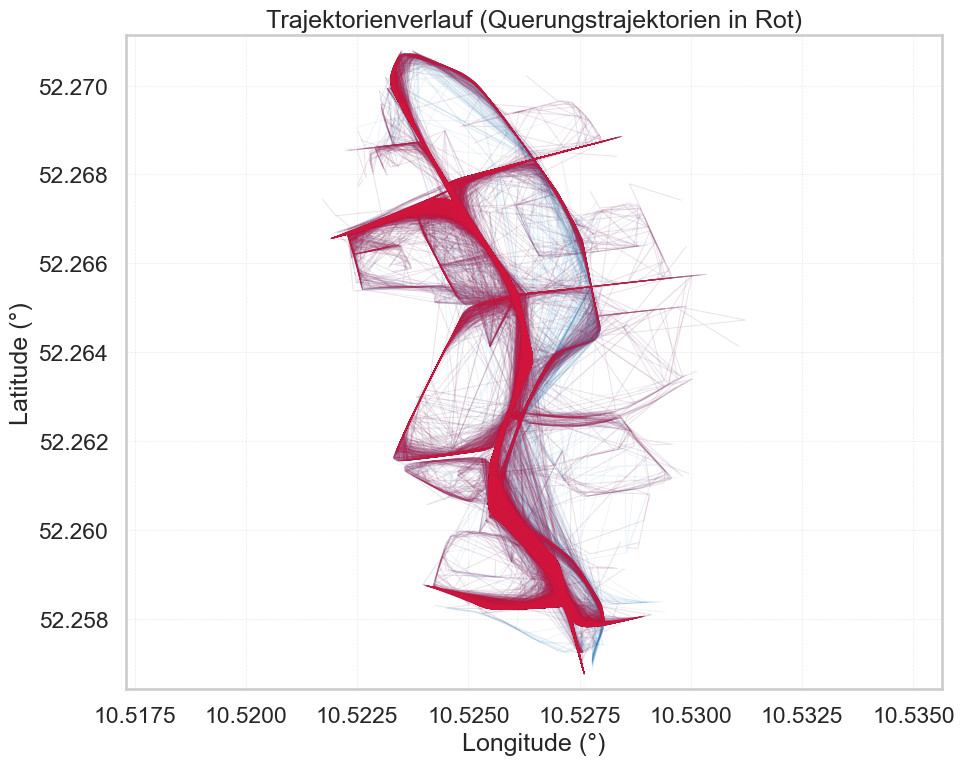

In [34]:
max_traj_to_plot = None
alpha_per_traj = 0.08 if max_traj_to_plot is None else min(0.6, 8 / max_traj_to_plot)
grouped = list(traj_points.groupby('traj_id', sort=False))
if max_traj_to_plot is not None:
    grouped = grouped[:max_traj_to_plot]
crossing_ids = set(crossings_df['Trajectory ID']) if not crossings_df.empty else set()

fig, ax = plt.subplots(figsize=(10, 8))
for traj_id, group in grouped:
    coords = group[['lon','lat']].dropna()
    if coords.shape[0] < 2:
        continue
    ax.plot(coords['lon'].values, coords['lat'].values, linewidth=0.7, alpha=alpha_per_traj, color='tab:blue')
if crossing_ids:
    for traj_id, group in grouped:
        if traj_id not in crossing_ids:
            continue
        coords = group[['lon','lat']].dropna()
        if coords.shape[0] < 2:
            continue
        ax.plot(coords['lon'].values, coords['lat'].values, linewidth=0.7, alpha=alpha_per_traj, color='crimson')
ax.set_title('Trajektorienverlauf (Querungstrajektorien in Rot)')
ax.set_xlabel('Longitude (\u00b0)'); ax.set_ylabel('Latitude (\u00b0)')
ax.set_aspect('equal', adjustable='datalim')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
valid_extent = traj_points[['lon','lat']].dropna()
if not valid_extent.empty:
    min_lon, max_lon = valid_extent['lon'].min(), valid_extent['lon'].max()
    min_lat, max_lat = valid_extent['lat'].min(), valid_extent['lat'].max()
    pad = max(max_lon - min_lon, max_lat - min_lat) * 0.02
    ax.set_xlim(min_lon - pad, max_lon + pad)
    ax.set_ylim(min_lat - pad, max_lat + pad)
plt.tight_layout(); plt.show()

## 7) Filter: Di–Do, ohne Ferien/Feiertage (2021) und Distanz-Cut \u2264 700 m
- Datumsebene statt exakter Timestamp-Vergleich (robuster)

In [35]:

def pick_col(df, candidates, name):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Keine passende Spalte für {name} gefunden. Kandidaten: {candidates}\nVorhandene Spalten: {list(df.columns)}")

# Spalten flexibel wählen
dep_col = pick_col(
    crossings_df, 
    ["Trip Departure Time", "Departure", "Line A Crossing Time", "line_a_time"], 
    "Abfahrts-/Referenzzeit"
)
dist_col = pick_col(
    crossings_df, 
    ["Distance Between Lines (m)", "distance_m_between_lines"], 
    "Distanz zwischen Linien"
)

# Zeitspalte sicher zu datetime wandeln (naiv/UTC egal)
dep_ts = pd.to_datetime(crossings_df[dep_col], errors="coerce", utc=True).dt.tz_convert(None)

# Wochentag: Di(1), Mi(2), Do(3)
mask_weekday = dep_ts.dt.weekday.isin([1, 2, 3])

# Beispielhafte Ferien/Feiertage (bei Bedarf anpassen/erweitern)
ferien_2021 = [
    pd.date_range("2021-02-01", "2021-02-02"),
    pd.date_range("2021-03-29", "2021-04-09"),
    pd.to_datetime(["2021-05-14", "2021-05-25"]),
    pd.date_range("2021-07-22", "2021-09-01"),
    pd.date_range("2021-10-18", "2021-10-29"),
    pd.date_range("2021-12-23", "2022-01-07"),
]
# zu Datumsmenge normalisieren
ferien_dates = pd.DatetimeIndex(
    np.concatenate([fr.values if hasattr(fr, "values") else np.array([fr.value]) for fr in ferien_2021])
).tz_localize("UTC").tz_convert(None).date

feiertage_2021 = pd.to_datetime([
    "2021-01-01","2021-04-02","2021-04-05","2021-05-01","2021-05-13","2021-05-24",
    "2021-10-03","2021-10-31","2021-12-25","2021-12-26"
]).date

dep_dates = dep_ts.dt.date
mask_ferien = pd.Series(dep_dates).isin(ferien_dates).to_numpy()
mask_feiertag = pd.Series(dep_dates).isin(feiertage_2021).to_numpy()

mask_valid = mask_weekday & (~mask_ferien) & (~mask_feiertag)

crossings_df_filtered = crossings_df.loc[mask_valid].reset_index(drop=True)

# Distanz-Cut anwenden (robust gegen Strings/NaN)
dist_series = pd.to_numeric(crossings_df_filtered[dist_col], errors="coerce")
crossings_df_filtered_distance = crossings_df_filtered.loc[dist_series <= DISTANCE_CUT_M].reset_index(drop=True)

print("Anzahl nach Filterung:", crossings_df_filtered_distance.shape[0])


# Nach deinem robusten Filter bis crossings_df_filtered ...

# 1) Spaltennamen auf "schön" normalisieren (idempotent)
crossings_df_filtered = crossings_df_filtered.rename(columns=COLUMN_RENAMES)

# 2) Distanzspalte robust wählen und Cut anwenden
if "Distance Between Lines (m)" in crossings_df_filtered.columns:
    dist_col = "Distance Between Lines (m)"
elif "distance_m_between_lines" in crossings_df_filtered.columns:
    dist_col = "distance_m_between_lines"
else:
    raise KeyError("Keine Distanzspalte gefunden. Erwartet: 'Distance Between Lines (m)' oder 'distance_m_between_lines'.")

dist_series = pd.to_numeric(crossings_df_filtered[dist_col], errors="coerce")
crossings_df_filtered_distance = crossings_df_filtered.loc[dist_series <= DISTANCE_CUT_M].reset_index(drop=True)

print("Anzahl nach Filterung:", crossings_df_filtered_distance.shape[0])

# 3) 'Segment Time of Day' sicherstellen (ohne or auf Series)
if "Segment Time of Day" not in crossings_df_filtered_distance.columns:
    if "Line A Crossing Time" in crossings_df_filtered_distance.columns:
        time_col = "Line A Crossing Time"
    elif "Trip Departure Time" in crossings_df_filtered_distance.columns:
        time_col = "Trip Departure Time"
    elif "line_a_time" in crossings_df_filtered_distance.columns:
        time_col = "line_a_time"
    else:
        raise KeyError("Keine Zeitspalte für Periodisierung gefunden.")
    ts = pd.to_datetime(crossings_df_filtered_distance[time_col], errors="coerce", utc=True).dt.tz_convert(None)
    crossings_df_filtered_distance["Segment Time of Day"] = ts.apply(determine_time_period)

Anzahl nach Filterung: 996
Anzahl nach Filterung: 996


## 8) Verteilungen und Auswertungen (kompakt)

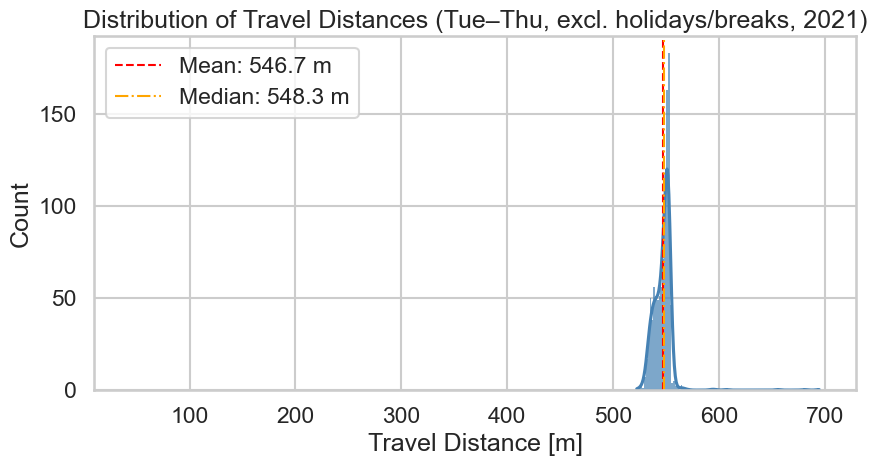

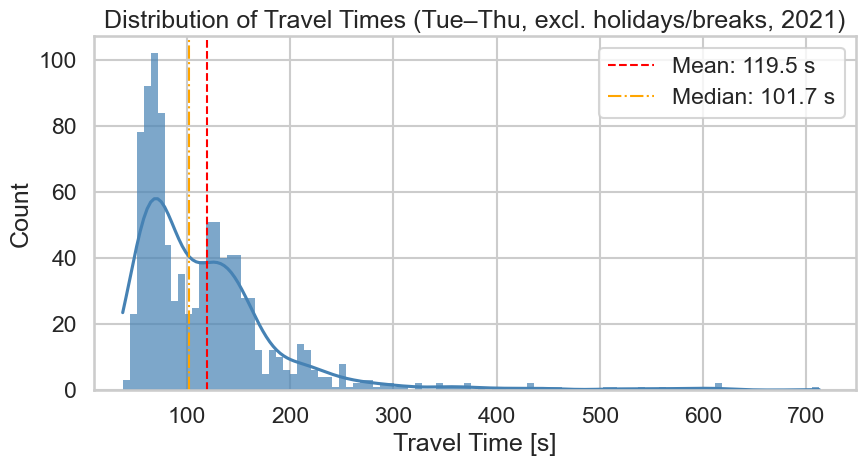

/var/folders/0m/qk4p0csd6_34gwkb9phn6gcw0000gn/T/ipykernel_84752/3890309124.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=crossings_df_filtered_distance, x='Segment Time of Day', y='Segment Travel Time (s)', order=order,


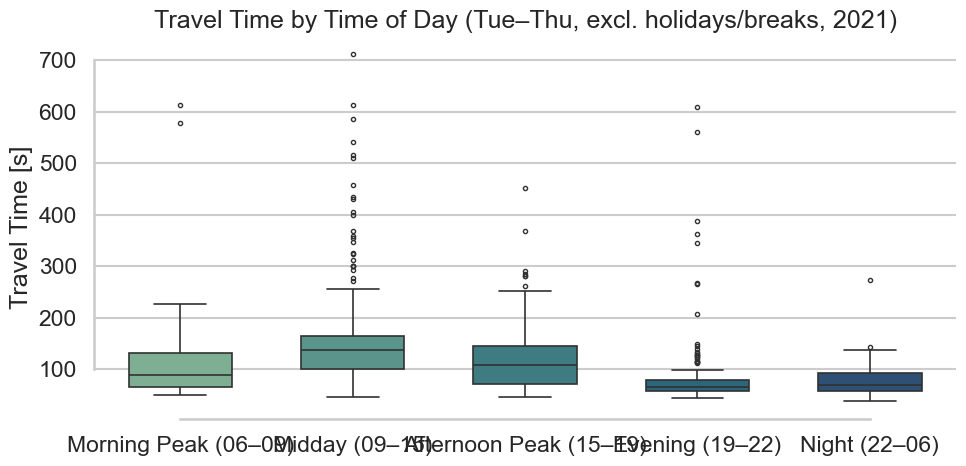

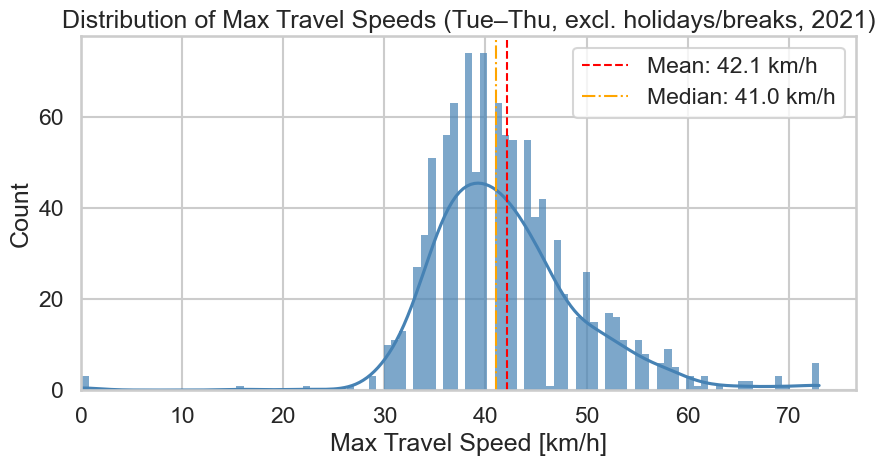

In [36]:
# Distanz-Verteilung
valid_distances = crossings_df_filtered_distance['Distance Between Lines (m)'].dropna()
fig, ax = plt.subplots(figsize=(9,5))
sns.histplot(data=valid_distances, bins=100, kde=True, color='steelblue', edgecolor='none', alpha=0.7, ax=ax)
mean_d, median_d = valid_distances.mean(), valid_distances.median()
ax.axvline(mean_d, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_d:.1f} m')
ax.axvline(median_d, color='orange', linestyle='-.', linewidth=1.5, label=f'Median: {median_d:.1f} m')
ax.set_title('Distribution of Travel Distances (Tue\u2013Thu, excl. holidays/breaks, 2021)')
ax.set_xlabel('Travel Distance [m]'); ax.set_ylabel('Count'); ax.legend()
ax.set_xlim(10, valid_distances.max()*1.05)
plt.tight_layout(); plt.show()

# Reisezeit-Verteilung
valid_times = crossings_df_filtered_distance['Segment Travel Time (s)'].dropna()
fig, ax = plt.subplots(figsize=(9,5))
sns.histplot(data=valid_times, bins=100, kde=True, color='steelblue', edgecolor='none', alpha=0.7, ax=ax)
mean_tt, median_tt = valid_times.mean(), valid_times.median()
ax.axvline(mean_tt, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_tt:.1f} s')
ax.axvline(median_tt, color='orange', linestyle='-.', linewidth=1.5, label=f'Median: {median_tt:.1f} s')
ax.set_title('Distribution of Travel Times (Tue\u2013Thu, excl. holidays/breaks, 2021)')
ax.set_xlabel('Travel Time [s]'); ax.set_ylabel('Count'); ax.legend()
ax.set_xlim(10, valid_times.max()*1.05)
plt.tight_layout(); plt.show()

# Boxplot nach Tageszeit
fig, ax = plt.subplots(figsize=(10,5))
order = ['Morning Peak (06\u201309)','Midday (09\u201315)','Afternoon Peak (15\u201319)','Evening (19\u201322)','Night (22\u201306)']
sns.boxplot(data=crossings_df_filtered_distance, x='Segment Time of Day', y='Segment Travel Time (s)', order=order,
            palette=sns.color_palette('crest', n_colors=5), width=0.6, fliersize=3, linewidth=1.2, ax=ax)
ax.set_title('Travel Time by Time of Day (Tue\u2013Thu, excl. holidays/breaks, 2021)')
ax.set_xlabel(''); ax.set_ylabel('Travel Time [s]')
ax.tick_params(axis='x', rotation=0)
sns.despine(trim=True)
plt.tight_layout(); plt.show()

# Verteilung Maximalgeschwindigkeit
series = pd.to_numeric(crossings_df_filtered_distance['Maximum Speed Between Lines (km/h)'], errors='coerce').dropna()
if not series.empty:
    cap = series.quantile(0.995)
    series_plot = series.clip(upper=cap)
    fig, ax = plt.subplots(figsize=(9,5))
    sns.histplot(data=series_plot, bins=100, kde=True, color='steelblue', edgecolor='none', alpha=0.7, ax=ax)
    ax.axvline(series.mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {series.mean():.1f} km/h")
    ax.axvline(series.median(), color='orange', linestyle='-.', linewidth=1.5, label=f"Median: {series.median():.1f} km/h")
    ax.set_title('Distribution of Max Travel Speeds (Tue\u2013Thu, excl. holidays/breaks, 2021)')
    ax.set_xlabel('Max Travel Speed [km/h]'); ax.set_ylabel('Count'); ax.legend()
    ax.set_xlim(left=max(0, series_plot.min()*0.95), right=series_plot.max()*1.05)
    plt.tight_layout(); plt.show()
else:
    print('Keine validen Geschwindigkeitswerte für Histogramm gefunden.')

## 9) Export vorbereiten und speichern

In [37]:
export_cols = [
    'Trajectory ID','Trip ID','Line A Crossing Time','Segment Time of Day','Segment Travel Time (s)',
    'Distance Between Lines (m)','Average Speed Between Lines (km/h)','Maximum Speed Between Lines (km/h)',
    'Line A Crossing Longitude','Line A Crossing Latitude','Line B Crossing Longitude','Line B Crossing Latitude',
    'Stops Between Lines (count)','Total Stop Time Between Lines (s)','Average Stop Duration Between Lines (s)',
    'Longest Stop Between Lines (s)','Stop Delay Between Lines (s)','Minimum Acceleration Between Lines (m/s^2)',
    'Maximum Acceleration Between Lines (m/s^2)','Average Positive Acceleration Between Lines (m/s^2)','Average Braking Between Lines (m/s^2)'
]
export = crossings_df_filtered_distance[export_cols].copy() if not crossings_df_filtered_distance.empty else pd.DataFrame(columns=export_cols)
export = export.rename(columns={'Line A Crossing Time': 'Departure Time'})
export.head(3)

,Trajectory ID,Trip ID,Departure Time,Segment Time of Day,Segment Travel Time (s),Distance Between Lines (m),Average Speed Between Lines (km/h),Maximum Speed Between Lines (km/h),Line A Crossing Longitude,Line A Crossing Latitude,...,Line B Crossing Latitude,Stops Between Lines (count),Total Stop Time Between Lines (s),Average Stop Duration Between Lines (s),Longest Stop Between Lines (s),Stop Delay Between Lines (s),Minimum Acceleration Between Lines (m/s^2),Maximum Acceleration Between Lines (m/s^2),Average Positive Acceleration Between Lines (m/s^2),Average Braking Between Lines (m/s^2)
0,-1098665640_1630557760,-1098665640_1630557760,2021-09-02 04:44:02.501426457,Night (22–06),60.994074,532.623611,31.436578,46.0,10.526264,52.263798,...,52.259208,0,0.0,0.0,0.0,0.0,-0.666667,0.851852,0.642002,-0.633187
1,1151731856_1630558753,1151731856_1630558753,2021-09-02 05:03:57.412912846,Night (22–06),74.908615,549.407389,26.403727,35.0,10.526425,52.263798,...,52.259220,0,0.0,0.0,0.0,0.0,-1.111111,0.805556,0.366204,-0.277778
2,1621654232_1630561104,1621654232_1630561104,2021-09-02 05:40:09.479531765,Night (22–06),98.244179,546.174160,20.013674,43.0,10.526430,52.263798,...,52.259222,1,30.0,30.0,30.0,30.0,-0.759259,0.796296,0.425926,-0.288010


In [38]:
out_path = 'FCD_Bohlweg_N_S_export.csv'
export.to_csv(out_path, index=False)
print(f'Export gespeichert: {out_path} ({export.shape[0]} Zeilen)')

Export gespeichert: FCD_Bohlweg_N_S_export.csv (996 Zeilen)
